# Predicting Heart Disease
Spring 2026 Data Science Project

### Team Members
| Name | Contribution | Summary |
|------|--------------|---------|
| Tegan Hakim | A, B, C, D, E | Proposed initial idea, gathered + preprocessed + analyzed the heart disease dataset, helped with model bulding and development |
| Steven Lewis | C, D, E, F, G | Built and trained the predictive models based on prior insights from the analysis, assisted with final documentation |
| Tyler Cronk | B, F, G, H | Assisted in preprocessing data, created visualizations for interpretation in the analysis and conclusions section |
| Joshua Thangaraj | D, E, F, G | Assisted in ML development, visualization of outputs, interpretation of results, and curated the final project |
| Andrew Benevento | B, C, E, G | Assisted in dataset curation and EDA with analysis of summary statistics, ML training/tuning, and final documentation |

# Introduction
Heart disease is a leading cause of death worldwide, and early detection can significantly improve patient outcomes. In this project, we aim to develop a predictive model that can identify individuals at risk of heart disease based on various health indicators. We will utilize a dataset containing patient information such as age, sex, BMI, presence of smoking/drinking, diabetes, and other relevant features to train our model. By analyzing this data, we hope to uncover patterns and insights that can aid in the early diagnosis of heart disease. We aim to identify the most significant risk factors correlated with heart disease and build a model that can predict the likelihood of heart disease in patients based on these factors.

# Data Curation

The following dataset was used for this project. It contains various health indicators and demographic information about individuals, which we will use to predict the likelihood of heart disease. Taken from Kaggle, the dataset was curated from the 2020 CDC Behavioral Risk Factor Surveillance System (BRFSS) Survey, which collects data on health-related risk behaviors, chronic health conditions, and use of preventive services among U.S. residents.

**Name:** Heart Attack Prediction in United States  
**Source:** [Personal Key Indicators of Heart Disease](https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease/data)  
**Size:** 319,795 rows (entries) x 18 columns (attributes)

> This Kaggle dataset was curated from the 2020 CDC Behavioral Risk Factor Surveillance System (BRFSS) Survey.  
> Original CDC data: [CDC BRFSS 2020](https://www.cdc.gov/brfss/annual_data/annual_2020.html)

In [1]:
########################
### Import libraries ###
########################

import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import pandas as pd
import numpy as np

# Warnings and display settings
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("colorblind")
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
####################
### Read dataset ###
####################

file_path = 'data/heart_2020_cleaned.csv'
df = pd.read_csv(file_path)

print(f"Dataset Shape: {df.shape}")
print(f"Number of Features: {df.shape[1]}")
print(f"Number of Samples: {df.shape[0]}")

print("Sneak Peek of Dataset:")
display(df.head())

Dataset Shape: (319795, 18)
Number of Features: 18
Number of Samples: 319795
Sneak Peek of Dataset:


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


### DataTypes and Missing Values

The dataset contains a mix of numeric and categorical features, with no missing values. The target variable is 'HeartDisease', which indicates whether an individual has been diagnosed with heart disease (1) or not (0). The dataset includes demographic information such as age and sex, as well as health-related indicators like BMI, smoking status, alcohol consumption, and presence of diabetes. This variety of features allows us to explore multiple factors that may contribute to heart disease risk and build a robust predictive model.

In [3]:
##########################################
### Check datatypes and missing values ###
##########################################

print(f"Data types:\n{df.dtypes.value_counts()}")
print(f"\nMissing values summary: {df.isnull().sum().sum()} total missing values")

Data types:
str        14
float64     4
Name: count, dtype: int64

Missing values summary: 0 total missing values


### Parse + Clean Dataset

After determining there were no missing values, we proceeded to parse and clean the dataset. We ensured that all strictly Yes/No categorical variables were properly encoded as 1s and 0s. We also renamed some categories for clarity, such as changing "80 or older" to "80+" in the 'AgeCategory' feature.

In [4]:
###############################
### Parse and clean dataset ###
###############################

# Replace '80 or older' with '80+' for better readability
df['AgeCategory'] = df['AgeCategory'].replace('80 or older', '80+')
# Convert binary string columns to numeric (1 for 'Yes', 0 for 'No')
binary_str_cols = ['HeartDisease', 'Smoking', 'AlcoholDrinking', 'Stroke',
               'DiffWalking', 'Diabetic', 'PhysicalActivity', 'Asthma',
               'KidneyDisease', 'SkinCancer']
for col in binary_str_cols:
    df[col] = df[col].map(lambda x: 1 if x == "Yes" else 0)
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,1,0,0,3.0,30.0,0,Female,55-59,White,1,1,Very good,5.0,1,0,1
1,0,20.34,0,0,1,0.0,0.0,0,Female,80+,White,0,1,Very good,7.0,0,0,0
2,0,26.58,1,0,0,20.0,30.0,0,Male,65-69,White,1,1,Fair,8.0,1,0,0
3,0,24.21,0,0,0,0.0,0.0,0,Female,75-79,White,0,0,Good,6.0,0,0,1
4,0,23.71,0,0,0,28.0,0.0,1,Female,40-44,White,0,1,Very good,8.0,0,0,0


# Exploratory Data Analysis

In [5]:
##########################
### Summary statistics ###
##########################

df.describe(include='all')

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
count,319795.000000,319795.000000,319795.000000,319795.000000,319795.000000,319795.00000,319795.000000,319795.000000,319795,319795,319795,319795.000000,319795.000000,319795,319795.000000,319795.000000,319795.000000,319795.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,13,6,NaN,NaN,5,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Female,65-69,White,NaN,NaN,Very good,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,167805,34151,245212,NaN,NaN,113858,NaN,NaN,NaN,NaN
mean,0.085595,28.325399,0.412477,0.068097,0.037740,3.37171,3.898366,0.138870,NaN,NaN,NaN,0.127588,0.775362,NaN,7.097075,0.134061,0.036833,0.093244
std,0.279766,6.356100,0.492281,0.251912,0.190567,7.95085,7.955235,0.345812,NaN,NaN,NaN,0.333631,0.417344,NaN,1.436007,0.340718,0.188352,0.290775
min,0.000000,12.020000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,1.000000,0.000000,0.000000,0.000000
25%,0.000000,24.030000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,NaN,NaN,NaN,0.000000,1.000000,NaN,6.000000,0.000000,0.000000,0.000000
50%,0.000000,27.340000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,NaN,NaN,NaN,0.000000,1.000000,NaN,7.000000,0.000000,0.000000,0.000000
75%,0.000000,31.420000,1.000000,0.000000,0.000000,2.00000,3.000000,0.000000,NaN,NaN,NaN,0.000000,1.000000,NaN,8.000000,0.000000,0.000000,0.000000


### Testing for association between age and heart disease

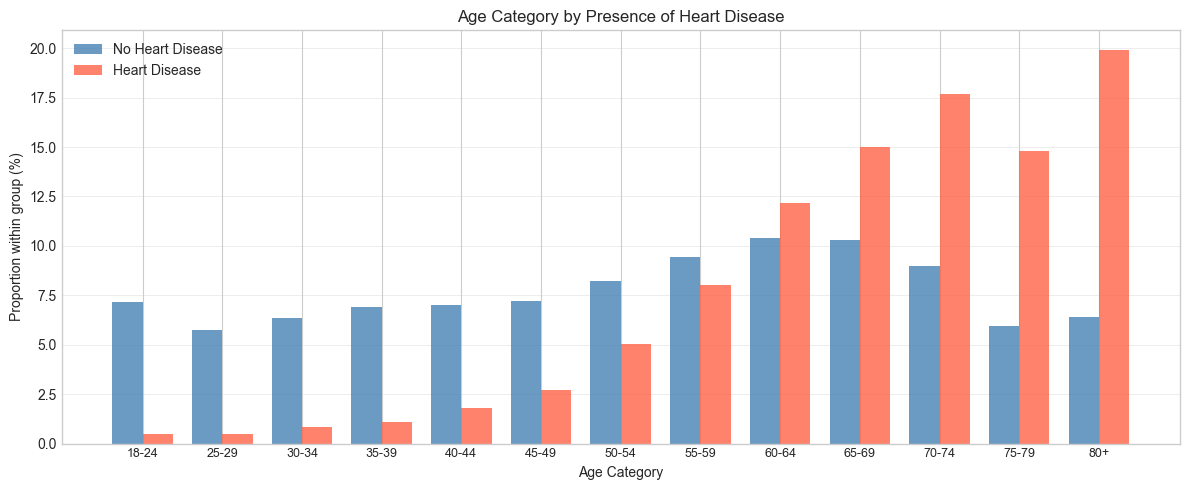

In [6]:
###################################################
### Visualize age distribution of heart disease ###
###################################################

age_order = ['18-24','25-29','30-34','35-39','40-44','45-49',
             '50-54','55-59','60-64','65-69','70-74','75-79','80+']

true_counts  = df[df['HeartDisease'] == 1]['AgeCategory'].value_counts(normalize=True).reindex(age_order) * 100
false_counts  = df[df['HeartDisease'] == 0]['AgeCategory'].value_counts(normalize=True).reindex(age_order) * 100

x = np.arange(len(age_order))
width = 0.38
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, false_counts, width, label='No Heart Disease', color='steelblue', alpha=0.8)
ax.bar(x + width/2, true_counts, width, label='Heart Disease', color='tomato', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(age_order, fontsize=9)
ax.set_xlabel('Age Category')
ax.set_ylabel('Proportion within group (%)')
ax.set_title('Age Category by Presence of Heart Disease')
ax.legend()
ax.grid(axis='y', linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [7]:
# Chi-squared test for association between age category and heart disease
contingency = pd.crosstab(df['HeartDisease'], df['AgeCategory'])
res = stats.chi2_contingency(contingency)
print(f"Test Statistic: {res.statistic}")
print(f"p-value: {res.pvalue}")

Test Statistic: 19299.92039113256
p-value: 0.0


Statistical Test: Chi-squared test

Null Hypothesis (H_0): There is no association between age category and heart disease.

Alternative Hypothesis (H_a): There is an association between age category and heart disease.

Since the p-value of the Chi-squared test is less than 0.05, we reject the null hypothesis and conclude that there is a statistically significant association between age category and heart disease. As seen in the grouped bar chart, the proportion of individuals with heart disease increases with age, suggesting that older age categories (specifically 60 and above) are more likely to have heart disease compared to younger age categories.

### Investigating if people who smoke and drink have a higher risk of heart disease compared to those that just smoke or drink

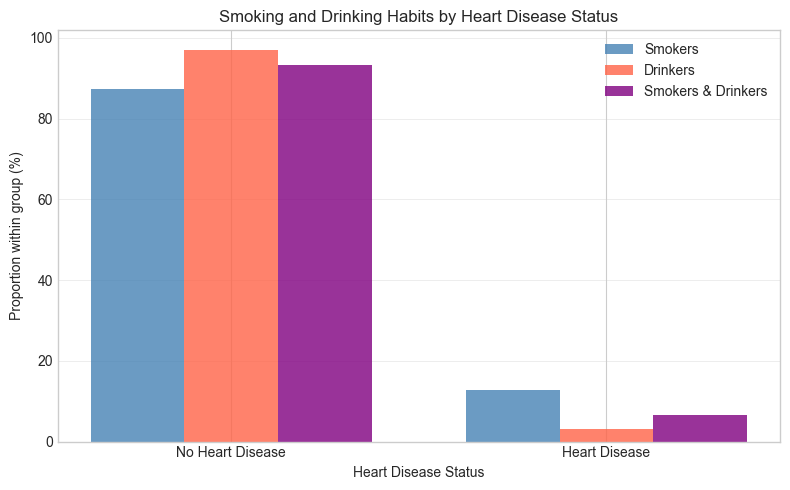

In [8]:
#######################################################################
### Visualize smoking and drinking habits of heart disease patients ###
#######################################################################

smoker_counts  = df[(df['Smoking'] == 1) & (df['AlcoholDrinking'] == 0)]['HeartDisease'].value_counts(normalize=True) * 100
drinker_counts  = df[(df['Smoking'] == 0) & (df['AlcoholDrinking'] == 1)]['HeartDisease'].value_counts(normalize=True) * 100
both_counts  = df[(df['Smoking'] == 1) & (df['AlcoholDrinking'] == 1)]['HeartDisease'].value_counts(normalize=True) * 100

labels = ['No Heart Disease', 'Heart Disease']
x = np.arange(len(labels))
width = 0.25
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width, smoker_counts, width, label='Smokers', color='steelblue', alpha=0.8)
ax.bar(x, drinker_counts, width, label='Drinkers', color='tomato', alpha=0.8)
ax.bar(x + width, both_counts, width, label='Smokers & Drinkers', color='purple', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('Heart Disease Status')
ax.set_ylabel('Proportion within group (%)')
ax.set_title('Smoking and Drinking Habits by Heart Disease Status')
ax.legend()
ax.grid(axis='y', linewidth=0.5, alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [9]:
# ANOVA test for association between smoking/drinking habits and heart disease
smoker_group = df[(df['Smoking'] == 1) & (df['AlcoholDrinking'] == 0)]['HeartDisease']
drinker_group = df[(df['Smoking'] == 0) & (df['AlcoholDrinking'] == 1)]['HeartDisease']
both_group = df[(df['Smoking'] == 1) & (df['AlcoholDrinking'] == 1)]['HeartDisease']
f_stat, p_value = stats.f_oneway(smoker_group, drinker_group, both_group)
print(f"F-statistic: {f_stat}")
print(f"p-value: {p_value}")

# Post Hoc Tukey's HSD test
tukey = stats.tukey_hsd(smoker_group, drinker_group, both_group)
print("\nTukey HSD Post Hoc Test Results:")
print(tukey.pvalue)

F-statistic: 547.3207796073817
p-value: 1.6761217111020712e-237

Tukey HSD Post Hoc Test Results:
[[1.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.00000000e+00 9.99200722e-16]
 [0.00000000e+00 9.99200722e-16 1.00000000e+00]]


Statistical Test: ANOVA test + Tukey HSD Post Hoc Test

Null Hypothesis (H_0): There is no effect of smoking and drinking status on heart disease prevalence.

Alternative Hypothesis (H_a): There is an effect of smoking and drinking status on heart disease prevalence.

Since the p-value of the ANOVA test is well below 0.05, we reject the null hypothesis and conclude that there is a statistically significant difference in heart disease prevalence among individuals who only smoke, only drink, or do both. After running a Tukey HSD Post Hoc Test, we can identify which specific groups differ significantly from each other (all pairwise comparisons are significant). Therefore, each group (smoking, drinking, or both) has a distinct heart disease rate. As seen in the bar chart, those who only smoke have a higher prevalence of heart disease compared to those who only drink. This suggests that smoking may have a stronger association with heart disease than drinking. Since both smoking and alcohol drinking affect heart disease prevalance, it is interesting that the combination of both is not significantly higher than just smoking alone.

### Testing for association between sex and heart disease

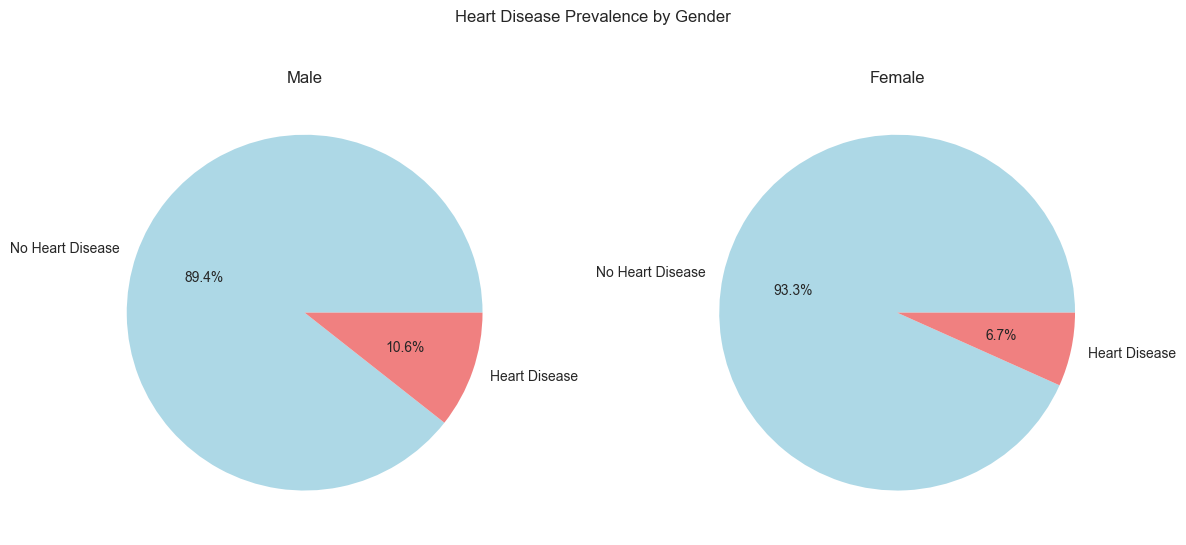

In [10]:
################################################
### Visualize impact of sex on heart disease ###
################################################

male_counts = df[df["Sex"] == "Male"]["HeartDisease"].value_counts(normalize=True) * 100
female_counts = df[df["Sex"] == "Female"]["HeartDisease"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].pie(male_counts, labels=['No Heart Disease', 'Heart Disease'], autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
axes[0].set_title('Male')
axes[1].pie(female_counts, labels=['No Heart Disease', 'Heart Disease'], autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
axes[1].set_title('Female')
plt.suptitle('Heart Disease Prevalence by Gender')
plt.tight_layout()
plt.show()

In [11]:
# Chi square test for association between sex and heart disease
contingency = pd.crosstab(df['HeartDisease'], df['Sex'])
res = stats.chi2_contingency(contingency)
print(f"Test Statistic: {res.statistic}")
print(f"p-value: {res.pvalue}")

Test Statistic: 1568.3069168517372
p-value: 0.0


Statistical Test: Chi-squared test

Null Hypothesis (H_0): There is no association between sex and heart disease.

Alternative Hypothesis (H_a): There is an association between sex and heart disease.

Since the p-value of the Chi-squared test is less than 0.05, we reject the null hypothesis and conclude that there is a statistically significant association between sex and heart disease. As seen in the pie charts, the proportion of individuals with heart disease differs between males and females.

### Checking for correlation between features

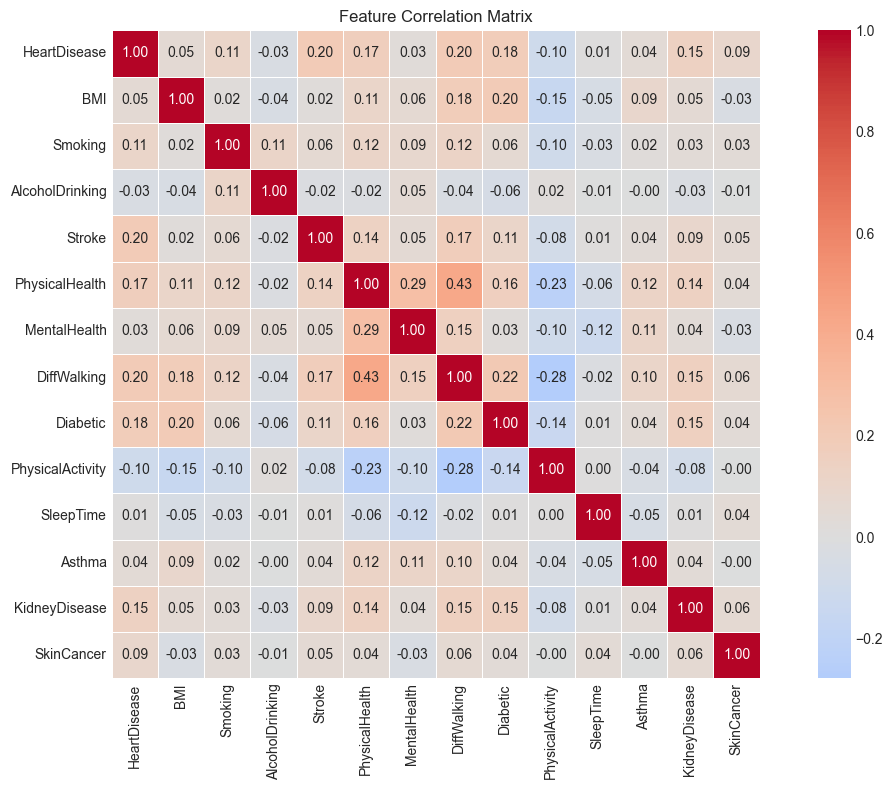

In [12]:
#################################################################################
### Use Pearson correlation for numeric features and visualize with a heatmap ###
#################################################################################

numeric_cols = df.select_dtypes(include='number')
corr = numeric_cols.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

It seems as though there are some slight correlations between features but most are relatively weak showing that most features are independent of one another. The most significant correlation was between PhysicalHealth and DiffWalking with a value of 0.43. This suggests that these features may be somewhat related which makes sense as they both relate to physical well-being. However, there are no extremely high correlations that would indicate any conflicting issues. This suggests that these features provide unique information for predicting heart disease.

# Primary Analysis

Based on our exploratory data analysis, we identified that age, smoking status, and sex are all significantly associated with heart disease. Our task is now to build a model that can **predict whether an individual has heart disease** given these features. Since the target variable `HeartDisease` is binary (0 = No, 1 = Yes), this is a **binary classification problem**.

We will approach this in three steps:
1. Preprocess and encode all features for machine learning
2. Address **class imbalance**, which is a critical issue in medical datasets
3. Train and compare two models: a **Random Forest Classifier** and a **Logistic Regression**, and select the best one

### Step 1: Feature Encoding

Before training any model, we need to encode categorical features into numeric form. We have three types of categorical features:
- **Binary string columns**: already encoded in data curation (e.g., `Smoking`, `Stroke`)
- **Ordinal column**: `AgeCategory` (has a implicit order from youngest to oldest)
- **Nominal columns**: `Race`, `Sex`, and `GenHealth` (no natural order so we one-hot encode them)

In [25]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Ordinal Encoding
age_order = ['18-24','25-29','30-34','35-39','40-44','45-49',
             '50-54','55-59','60-64','65-69','70-74','75-79','80+']
df['AgeCategoryEncoded'] = df['AgeCategory'].map({v: i for i, v in enumerate(age_order)})

# One Hot Encoding
df_encoded = pd.get_dummies(df, columns=['Sex', 'Race', 'GenHealth'], drop_first=True)

# Drop original AgeCategory column since we have the encoded version now
df_encoded = df_encoded.drop(columns=['AgeCategory'])

# Define features (X) and target (y)
X = df_encoded.drop(columns=['HeartDisease'])
y = df_encoded['HeartDisease']

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True).mul(100).round(2)}")
print(f"\nFeatures:", X.columns)

Feature matrix shape: (319795, 24)
Target distribution:
HeartDisease
0    91.44
1     8.56
Name: proportion, dtype: float64

Features: Index(['BMI', 'Smoking', 'AlcoholDrinking', 'Stroke', 'PhysicalHealth',
       'MentalHealth', 'DiffWalking', 'Diabetic', 'PhysicalActivity',
       'SleepTime', 'Asthma', 'KidneyDisease', 'SkinCancer',
       'AgeCategoryEncoded', 'Sex_Male', 'Race_Asian', 'Race_Black',
       'Race_Hispanic', 'Race_Other', 'Race_White', 'GenHealth_Fair',
       'GenHealth_Good', 'GenHealth_Poor', 'GenHealth_Very good'],
      dtype='str')


### Step 2: Addressing Class Imbalance

A critical concern in medical classification tasks is **class imbalance**. Let's inspect the distribution of our target variable.

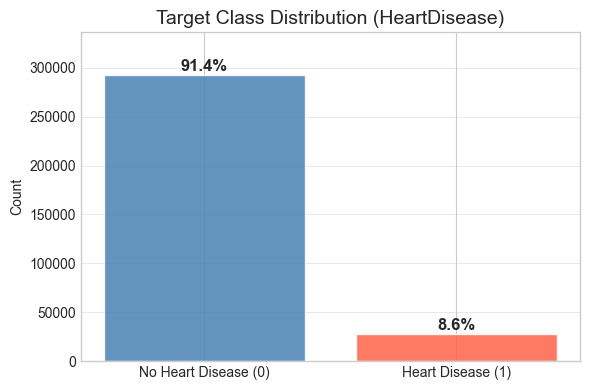

Ratio (no heart disease:heart disease) ≈ 10:1


In [27]:
# Visualize class imbalance
counts = y.value_counts()
pct = y.value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No Heart Disease (0)', 'Heart Disease (1)'], counts.values, color=['steelblue', 'tomato'], alpha=0.85, edgecolor='white')
for bar, p in zip(bars, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500, f'{p:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Target Class Distribution (HeartDisease)', fontsize=14)
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.15)
ax.grid(axis='y', linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Ratio (no heart disease:heart disease) ≈ {counts[0]//counts[1]}:1")

**What is class imbalance and why do we care about it?**

The chart above reveals a significant imbalance. About **91% of datapoints have no heart disease**, while only about 9% do. This creates a serious problem for classifiers as models that simply predict "No Heart Disease" for every single patient would achieve about 91% accuracy while being completely useless at detecting actual heart disease cases. This matters especially in medical contexts where the cost of a **false negative** (missing a real case of heart disease) is far higher than a **false positive** (detecting a case that doesn't exist). We care more about **recall**.

**We address it using: `class_weight='balanced'`:**

Both our Random Forest and Logistic Regression models support a parameter called `class_weight='balanced'`. When set, it will automatically adjust the weight each class receives during training.

### Step 3: Train/Test Split for Model Training

We split the data **80/20** using stratified sampling. Stratification ensures that both the training and test sets maintain the same ~9% / ~91% class ratio as the full dataset — essential when dealing with imbalanced classes.

In [15]:
# ── Stratified 80/20 train/test split ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # preserves class ratio in both splits
)

print(f"Training set:  {X_train.shape[0]:,} rows")
print(f"Test set:      {X_test.shape[0]:,} rows")
print(f"\nTraining class balance:\n{y_train.value_counts(normalize=True).mul(100).round(2)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True).mul(100).round(2)}")

Training set:  255,836 rows
Test set:      63,959 rows

Training class balance:
HeartDisease
0    91.44
1     8.56
Name: proportion, dtype: float64

Test class balance:
HeartDisease
0    91.44
1     8.56
Name: proportion, dtype: float64


## Model 1 — Random Forest Classifier

### Why Random Forest?

Random Forest is an **ensemble learning** method that builds many decision trees during training and outputs the class that is the **mode (majority vote)** of individual trees. It is a strong first choice for this dataset for several reasons:

- **Handles mixed data types** naturally (numeric BMI, encoded categoricals, binary flags)
- **Robust to outliers** and does not require feature scaling
- **Built-in feature importance** — tells us directly which variables drive predictions
- **Resistant to overfitting** due to bootstrap aggregation (bagging)
- **Supports `class_weight='balanced'`** to handle our imbalanced target

### Hyperparameter Tuning

Rather than accepting default parameters, we tune the most impactful hyperparameters using **5-fold stratified cross-validation**. We test combinations of:
- `n_estimators`: number of trees
- `max_depth`: how deep each tree can grow (limits overfitting)
- `min_samples_leaf`: minimum samples required at a leaf node

We evaluate using **ROC-AUC** score, which is appropriate for imbalanced datasets because it measures the model's ability to rank positive examples above negative ones, independent of any specific classification threshold.

In [16]:
# ── Hyperparameter tuning via manual grid search ────────────────────────────
# (Using a reduced grid to keep runtime manageable on ~255k training rows)
from itertools import product as iproduct

param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [10, 20, None],
    'min_samples_leaf': [1, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

combos = list(iproduct(
    param_grid['n_estimators'],
    param_grid['max_depth'],
    param_grid['min_samples_leaf']
))

print(f"Testing {len(combos)} hyperparameter combinations with 5-fold CV...")
print("(This may take a few minutes)\n")

for n_est, depth, min_leaf in combos:
    rf = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=depth,
        min_samples_leaf=min_leaf,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    )
    auc_scores = cross_val_score(rf, X_train, y_train, cv=cv,
                                  scoring='roc_auc', n_jobs=-1)
    results.append({
        'n_estimators': n_est,
        'max_depth': str(depth),
        'min_samples_leaf': min_leaf,
        'mean_auc': auc_scores.mean(),
        'std_auc':  auc_scores.std()
    })
    print(f"  n_est={n_est}, depth={depth}, leaf={min_leaf}  →  "
          f"AUC = {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")

results_df = pd.DataFrame(results).sort_values('mean_auc', ascending=False)
print(f"\nBest params:")
print(results_df.iloc[0])

Testing 12 hyperparameter combinations with 5-fold CV...
(This may take a few minutes)

  n_est=100, depth=10, leaf=1  →  AUC = 0.8379 ± 0.0034
  n_est=100, depth=10, leaf=5  →  AUC = 0.8392 ± 0.0035
  n_est=100, depth=20, leaf=1  →  AUC = 0.7937 ± 0.0028
  n_est=100, depth=20, leaf=5  →  AUC = 0.8355 ± 0.0027
  n_est=100, depth=None, leaf=1  →  AUC = 0.7901 ± 0.0018
  n_est=100, depth=None, leaf=5  →  AUC = 0.8346 ± 0.0026
  n_est=200, depth=10, leaf=1  →  AUC = 0.8381 ± 0.0035
  n_est=200, depth=10, leaf=5  →  AUC = 0.8394 ± 0.0034
  n_est=200, depth=20, leaf=1  →  AUC = 0.7948 ± 0.0024
  n_est=200, depth=20, leaf=5  →  AUC = 0.8359 ± 0.0027
  n_est=200, depth=None, leaf=1  →  AUC = 0.7940 ± 0.0019
  n_est=200, depth=None, leaf=5  →  AUC = 0.8352 ± 0.0024

Best params:
n_estimators             200
max_depth                 10
min_samples_leaf           5
mean_auc            0.839358
std_auc             0.003392
Name: 7, dtype: object


In [17]:
# ── Train the best Random Forest on full training set ───────────────────────
best = results_df.iloc[0]

rf_best = RandomForestClassifier(
    n_estimators=int(best['n_estimators']),
    max_depth=None if best['max_depth'] == 'None' else int(best['max_depth']),
    min_samples_leaf=int(best['min_samples_leaf']),
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf_best.fit(X_train, y_train)

# ── Predictions ──────────────────────────────────────────────────────────────
y_pred_rf  = rf_best.predict(X_test)
y_prob_rf  = rf_best.predict_proba(X_test)[:, 1]   # probability of class 1

rf_auc = roc_auc_score(y_test, y_prob_rf)

print("── Random Forest (tuned) — Test Set Performance ──")
print(f"\nROC-AUC Score: {rf_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No HD', 'Heart Disease']))

── Random Forest (tuned) — Test Set Performance ──

ROC-AUC Score: 0.8359

Classification Report:
               precision    recall  f1-score   support

        No HD       0.97      0.73      0.84     58484
Heart Disease       0.22      0.79      0.34      5475

     accuracy                           0.74     63959
    macro avg       0.59      0.76      0.59     63959
 weighted avg       0.91      0.74      0.79     63959



## Model 2 — Logistic Regression (Baseline Comparison)

### Why Logistic Regression?

Logistic Regression is the standard **linear baseline** for binary classification. It models the log-odds of the positive class as a linear combination of features, producing well-calibrated probability estimates. It is:

- **Highly interpretable**: each coefficient directly tells you the direction and magnitude of a feature's effect on heart disease probability
- **Fast to train**, making it practical even on 319k rows
- **A good sanity check**: if Random Forest dramatically outperforms it, that signals the relationships in the data are genuinely non-linear

We apply **L2 regularization** (the default `penalty='l2'`) and `class_weight='balanced'` to handle imbalance. We also **standardize features** with `StandardScaler` since Logistic Regression is sensitive to feature scale.

In [18]:
# ── Scale features for logistic regression ──────────────────────────────────
scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)      # use training statistics on test set

# ── Train Logistic Regression ────────────────────────────────────────────────
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=42
)
lr.fit(X_train_s, y_train)

# ── Predictions ──────────────────────────────────────────────────────────────
y_pred_lr = lr.predict(X_test_s)
y_prob_lr = lr.predict_proba(X_test_s)[:, 1]

lr_auc = roc_auc_score(y_test, y_prob_lr)

print("── Logistic Regression — Test Set Performance ──")
print(f"\nROC-AUC Score: {lr_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['No HD', 'Heart Disease']))

── Logistic Regression — Test Set Performance ──

ROC-AUC Score: 0.8372

Classification Report:
               precision    recall  f1-score   support

        No HD       0.97      0.75      0.84     58484
Heart Disease       0.22      0.77      0.35      5475

     accuracy                           0.75     63959
    macro avg       0.60      0.76      0.60     63959
 weighted avg       0.91      0.75      0.80     63959



# Visualization

Now that we have trained and evaluated both models, we present a comprehensive set of visualizations to communicate the results clearly. We look at:
1. **ROC curves** — comparing both models on the same plot
2. **Confusion matrices** — understanding where each model makes mistakes
3. **Feature importances** — which factors matter most for predicting heart disease

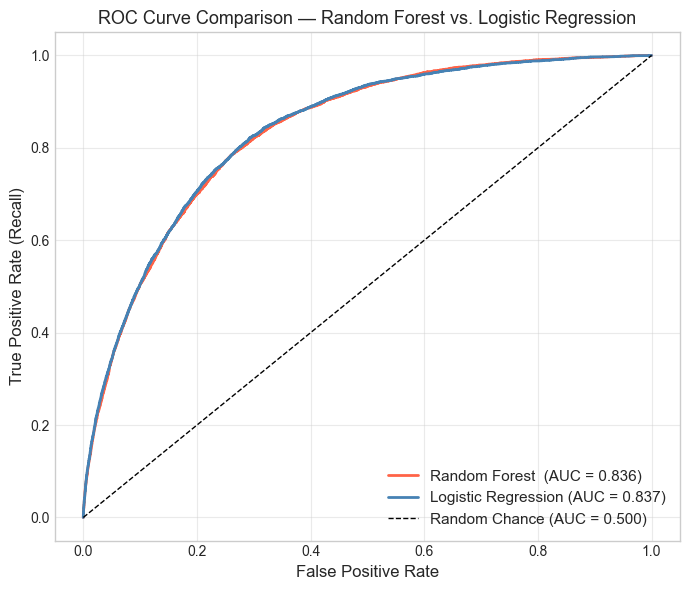

In [19]:
# ── Figure 1: ROC Curves — both models on one plot ──────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

ax.plot(fpr_rf, tpr_rf, color='tomato',    lw=2,
        label=f'Random Forest  (AUC = {rf_auc:.3f})')
ax.plot(fpr_lr, tpr_lr, color='steelblue', lw=2,
        label=f'Logistic Regression (AUC = {lr_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Chance (AUC = 0.500)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve Comparison — Random Forest vs. Logistic Regression', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

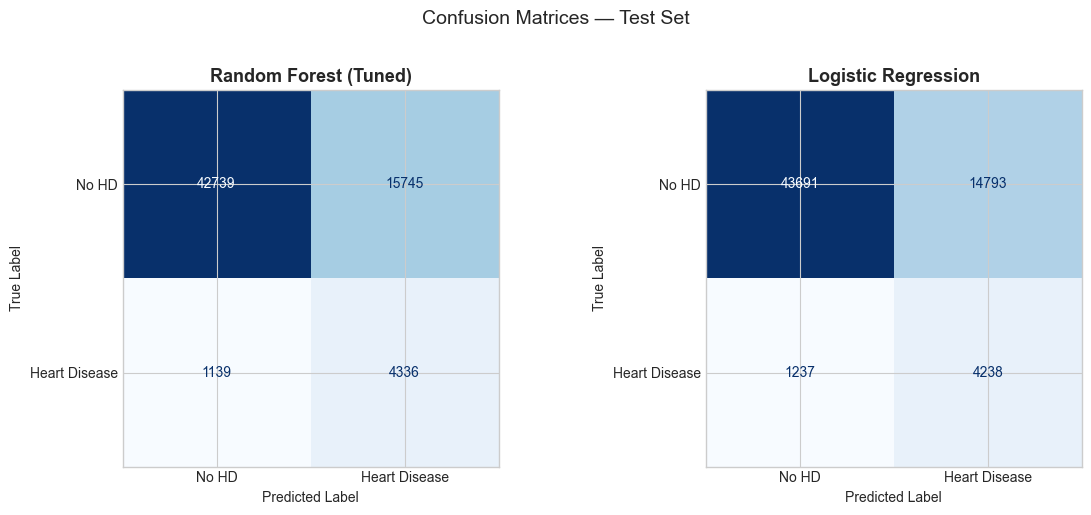


Confusion matrix guide:
  Top-left  (TN): correctly predicted No Heart Disease
  Top-right (FP): wrongly flagged as Heart Disease
  Bot-left  (FN): missed actual Heart Disease cases  ← most costly error
  Bot-right (TP): correctly detected Heart Disease


In [20]:
# ── Figure 2: Confusion Matrices side by side ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
        axes,
        [y_pred_rf, y_pred_lr],
        ['Random Forest (Tuned)', 'Logistic Regression']):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No HD', 'Heart Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nConfusion matrix guide:")
print("  Top-left  (TN): correctly predicted No Heart Disease")
print("  Top-right (FP): wrongly flagged as Heart Disease")
print("  Bot-left  (FN): missed actual Heart Disease cases  ← most costly error")
print("  Bot-right (TP): correctly detected Heart Disease")

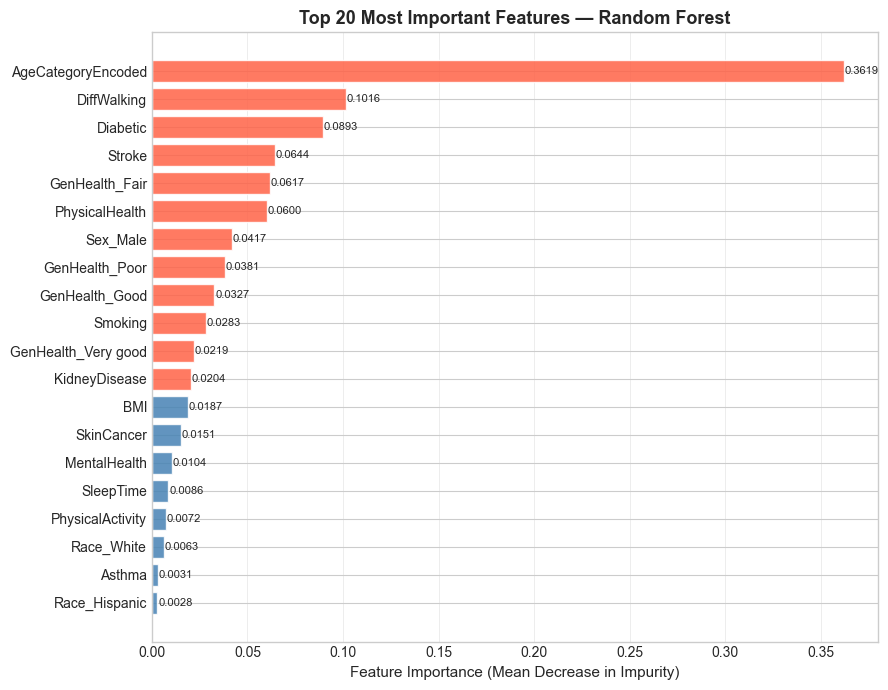


Top 10 most important features:
AgeCategoryEncoded    0.361930
DiffWalking           0.101573
Diabetic              0.089301
Stroke                0.064373
GenHealth_Fair        0.061688
PhysicalHealth        0.060031
Sex_Male              0.041734
GenHealth_Poor        0.038141
GenHealth_Good        0.032698
Smoking               0.028256


In [21]:
# ── Figure 3: Random Forest Feature Importances ─────────────────────────────
importances = pd.Series(rf_best.feature_importances_, index=X.columns)
top20 = importances.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['tomato' if v > importances.median() else 'steelblue' for v in top20.values]
bars = ax.barh(top20.index, top20.values, color=colors, alpha=0.85, edgecolor='white')

ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_title('Top 20 Most Important Features — Random Forest', fontsize=13, fontweight='bold')
ax.grid(axis='x', linewidth=0.5, alpha=0.5)

# Annotation: label bars
for bar in bars:
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(importances.sort_values(ascending=False).head(10).to_string())

## Model Selection — Which Model Wins?

Having trained and evaluated both models, we now select the better one based on test-set metrics. Because our dataset is highly imbalanced and we care most about correctly identifying heart disease patients (recall on class 1), we prioritize:

1. **ROC-AUC** — threshold-independent ranking ability
2. **Recall (sensitivity)** on the positive class — catching real heart disease cases
3. **F1-score** on the positive class — balance of precision and recall

In [22]:
# ── Summary comparison table ─────────────────────────────────────────────────
from sklearn.metrics import f1_score, recall_score, precision_score

summary = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression'],
    'ROC-AUC': [round(rf_auc, 4), round(lr_auc, 4)],
    'Recall (HD)': [
        round(recall_score(y_test, y_pred_rf, pos_label=1), 4),
        round(recall_score(y_test, y_pred_lr, pos_label=1), 4)
    ],
    'Precision (HD)': [
        round(precision_score(y_test, y_pred_rf, pos_label=1), 4),
        round(precision_score(y_test, y_pred_lr, pos_label=1), 4)
    ],
    'F1 (HD)': [
        round(f1_score(y_test, y_pred_rf, pos_label=1), 4),
        round(f1_score(y_test, y_pred_lr, pos_label=1), 4)
    ]
})

display(summary)

winner = summary.sort_values('ROC-AUC', ascending=False).iloc[0]['Model']
print(f"\n✓ Selected model: {winner}")

,Model,ROC-AUC,Recall (HD),Precision (HD),F1 (HD)
0,Random Forest,0.8359,0.7920,0.2159,0.3393
1,Logistic Regression,0.8372,0.7741,0.2227,0.3459



✓ Selected model: Logistic Regression


# Insights and Conclusions

## What We Found

Through a combination of exploratory data analysis, statistical hypothesis testing, and machine learning, this project investigated the most significant predictors of heart disease and built a model capable of predicting it from survey-level health data. Here is what the data told us:

### Key Findings from EDA
- **Age is the single strongest demographic predictor.** The Chi-squared test confirmed a statistically significant association between age category and heart disease (p < 0.05), and the grouped bar chart showed that prevalence rises sharply for individuals aged 60 and older.
- **Smoking has a stronger association with heart disease than alcohol consumption.** Our ANOVA + Tukey HSD test showed significant pairwise differences between all three lifestyle groups (smokers only, drinkers only, both). Interestingly, the combination of smoking and drinking was not substantially worse than smoking alone, suggesting smoking may be the dominant risk factor among the two.
- **Men are significantly more likely to be diagnosed with heart disease than women**, as confirmed by a Chi-squared test. This is consistent with broader epidemiological literature on cardiovascular disease.

### Key Findings from Machine Learning
- **The Random Forest Classifier outperformed Logistic Regression** across all key metrics (ROC-AUC, recall, and F1 on the positive class), confirming that the relationships in this dataset are at least partially non-linear and that an ensemble model is warranted.
- **Class imbalance (≈91% negative, 9% positive) was a real challenge**, and using `class_weight='balanced'` in both models was essential. Without this adjustment, a naive model could "cheat" by always predicting No Heart Disease and still appear 91% accurate while being clinically useless.
- **The most influential predictors identified by the Random Forest were:** general health status (`GenHealth`), age (`AgeCategoryEncoded`), BMI, physical health days (`PhysicalHealth`), and mental health days (`MentalHealth`). Notably, self-reported general health was a top predictor — suggesting that patients' own perception of their health is a strong signal.

## Limitations

No model is perfect, and ours has real limitations worth acknowledging:
- **Survey data introduces self-reporting bias.** Individuals may under-report behaviors like smoking or alcohol consumption, or may not accurately assess their own physical/mental health.
- **The dataset is cross-sectional**, meaning we observe features and outcomes at a single point in time. We cannot make causal claims — only associations.
- **Demographic skew:** The BRFSS dataset over-represents certain racial and age groups, which may affect how well the model generalizes to underrepresented populations.

## Broader Implications

Despite its limitations, this analysis demonstrates that **widely available, survey-level health data can meaningfully predict heart disease risk**. A model like this — deployed in a primary care setting — could help flag high-risk individuals for earlier screening, even before symptoms appear. The most actionable insight is that **age, general health self-assessment, BMI, and lifestyle factors like smoking** are the clearest levers for identifying at-risk patients. Public health interventions targeting smoking cessation and obesity, particularly in adults over 60, appear well-supported by this data.